# Deforestation detection -- POC

Comparing two classifications of the same area, three years apart, to look for `Forest -> something else` transitions -- the same idea used by real forest-loss monitoring tools (e.g. Global Forest Watch), built here with the existing tiling/inference logic (`scripts/deforestation_poc.py`, a standalone script -- doesn't touch the production pipeline).

**Area**: the Harz mountains, Germany -- hit by a well-documented, large-scale bark-beetle/drought dieback in 2018-2020.

**Dates**: August 2017 (before) vs. September 2020 (after), same MGRS tile (32UPC), both near-zero cloud cover.

**⚠️ Read this before the results below**: `REFLECTANCE_MAX=5600` was calibrated for the Paris scene used elsewhere in this project (label-free matching against EuroSAT's own pixel statistics). Nothing guarantees that calibration transfers to a different region, sun angle, and season. The raw results here are **implausible** at face value -- `Forest` increases from 2017 to 2020, the opposite of the known dieback -- and `SeaLake` implausibly covers most of the area in 2017, which doesn't match a mountain/forest landscape at all. This is almost certainly a calibration artifact (mountain shadow being misread as water, at a different rate on each date), not real land-cover change. This notebook demonstrates the **change-detection mechanism**, not a trustworthy deforestation measurement -- fixing that would mean recalibrating `REFLECTANCE_MAX` for this specific region first.

In [1]:
import json
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

POC_DIR = Path("../data/outputs/deforestation_poc")
TILE_SIZE = 64

before = np.load(POC_DIR / "before" / "land_use_grid_smoothed.npy", allow_pickle=True)
after = np.load(POC_DIR / "after" / "land_use_grid_smoothed.npy", allow_pickle=True)

with open("../data/eurosat_stats.json") as f:
    classes = json.load(f)["classes"]

# Same semantic palette as notebook 05 -- greens for vegetation, gold/brown
# for cropland, red/gray for built-up, blue for water.
CLASS_COLORS = {
    "AnnualCrop": "#D9A441",
    "Forest": "#1B6B3A",
    "HerbaceousVegetation": "#8FBF5C",
    "Highway": "#6B6B6B",
    "Industrial": "#7D5A8C",
    "Pasture": "#C8C87A",
    "PermanentCrop": "#A8651E",
    "Residential": "#D9645C",
    "River": "#4A90D9",
    "SeaLake": "#1E4E85",
}
class_to_idx = {c: i for i, c in enumerate(classes)}
colors = [CLASS_COLORS[c] for c in classes]
cmap = ListedColormap(colors)

print(f"Grid shape: {before.shape} (before), {after.shape} (after)")
print(f"\nBefore (2017): {dict(Counter(before.flatten()))}")
print(f"After  (2020): {dict(Counter(after.flatten()))}")

Grid shape: (53, 49) (before), (53, 49) (after)

Before (2017): {'AnnualCrop': 363, 'Pasture': 105, 'SeaLake': 1847, 'Forest': 203, 'Highway': 1, 'River': 2, 'HerbaceousVegetation': 74, 'Industrial': 2}
After  (2020): {'AnnualCrop': 306, 'Pasture': 168, 'SeaLake': 858, 'Forest': 1106, 'HerbaceousVegetation': 158, 'Highway': 1}


## RGB composites for both dates

In [2]:
def stretch(band, low=2, high=98):
    lo, hi = np.percentile(band, [low, high])
    return np.clip((band.astype(np.float32) - lo) / (hi - lo), 0, 1)


def build_composite(label, grid_shape):
    tiles_dir = POC_DIR / label / "tiles"
    n_rows, n_cols = grid_shape
    composite = np.zeros((n_rows * TILE_SIZE, n_cols * TILE_SIZE, 3), dtype=np.float32)
    for i in range(n_rows):
        for j in range(n_cols):
            tile = np.load(tiles_dir / f"tile_{i:03d}_{j:03d}.npy")
            composite[i * TILE_SIZE : (i + 1) * TILE_SIZE, j * TILE_SIZE : (j + 1) * TILE_SIZE, :] = tile
    return np.stack([stretch(composite[..., c]) for c in range(3)], axis=-1)


composite_before = build_composite("before", before.shape)
composite_after = build_composite("after", after.shape)
print(f"Composite shape: {composite_after.shape}")

Composite shape: (3392, 3136, 3)


## Side by side: imagery + classification, both dates

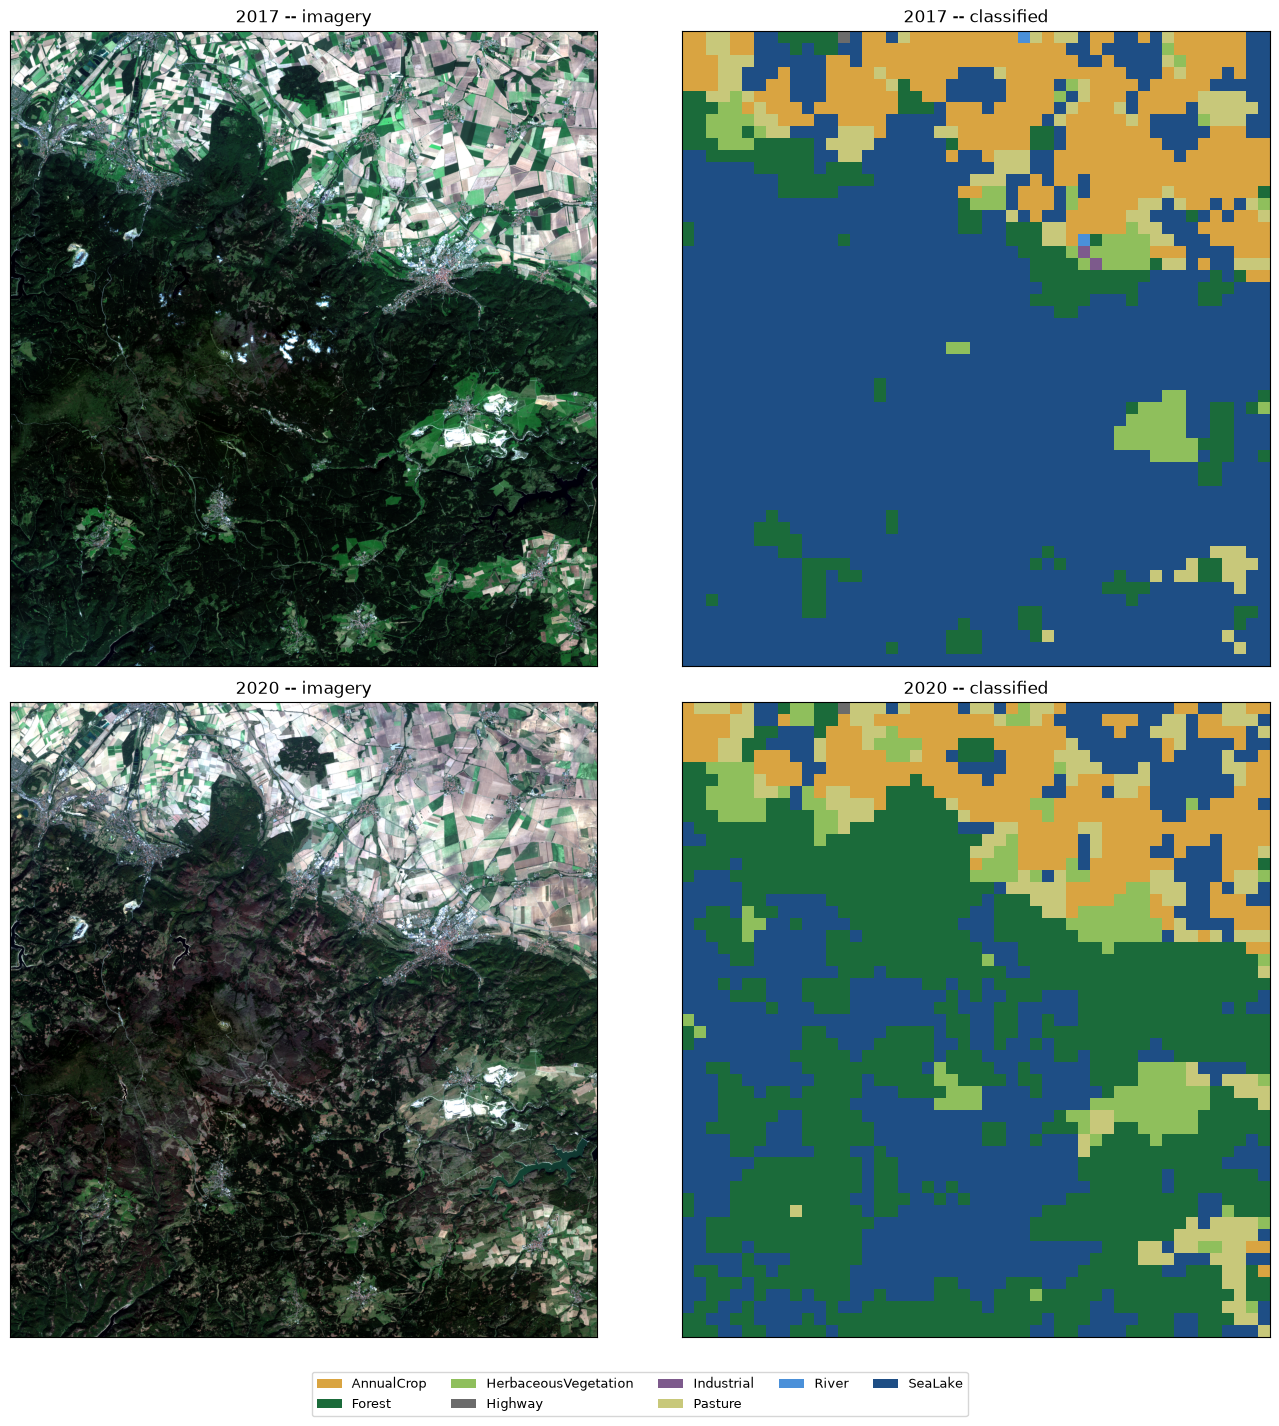

In [3]:
def to_index_map(grid):
    idx_map = np.zeros(grid.shape, dtype=int)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            idx_map[i, j] = class_to_idx[grid[i, j]]
    return idx_map


fig, axes = plt.subplots(2, 2, figsize=(14, 14))

axes[0, 0].imshow(composite_before)
axes[0, 0].set_title("2017 -- imagery")
axes[0, 1].imshow(to_index_map(before), cmap=cmap, vmin=0, vmax=len(classes) - 1)
axes[0, 1].set_title("2017 -- classified")

axes[1, 0].imshow(composite_after)
axes[1, 0].set_title("2020 -- imagery")
axes[1, 1].imshow(to_index_map(after), cmap=cmap, vmin=0, vmax=len(classes) - 1)
axes[1, 1].set_title("2020 -- classified")

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=CLASS_COLORS[c], label=c)
    for c in classes if c in set(before.flatten()) | set(after.flatten())
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## The diff: `Forest -> something else`

The actual change-detection step: flag every tile that was `Forest` in 2017 and isn't anymore in 2020. Given the calibration caveat above, treat the highlighted tiles as "where the mechanism found a transition", not as confirmed deforestation.

33 / 2597 tiles flagged as Forest -> other (1.3%)


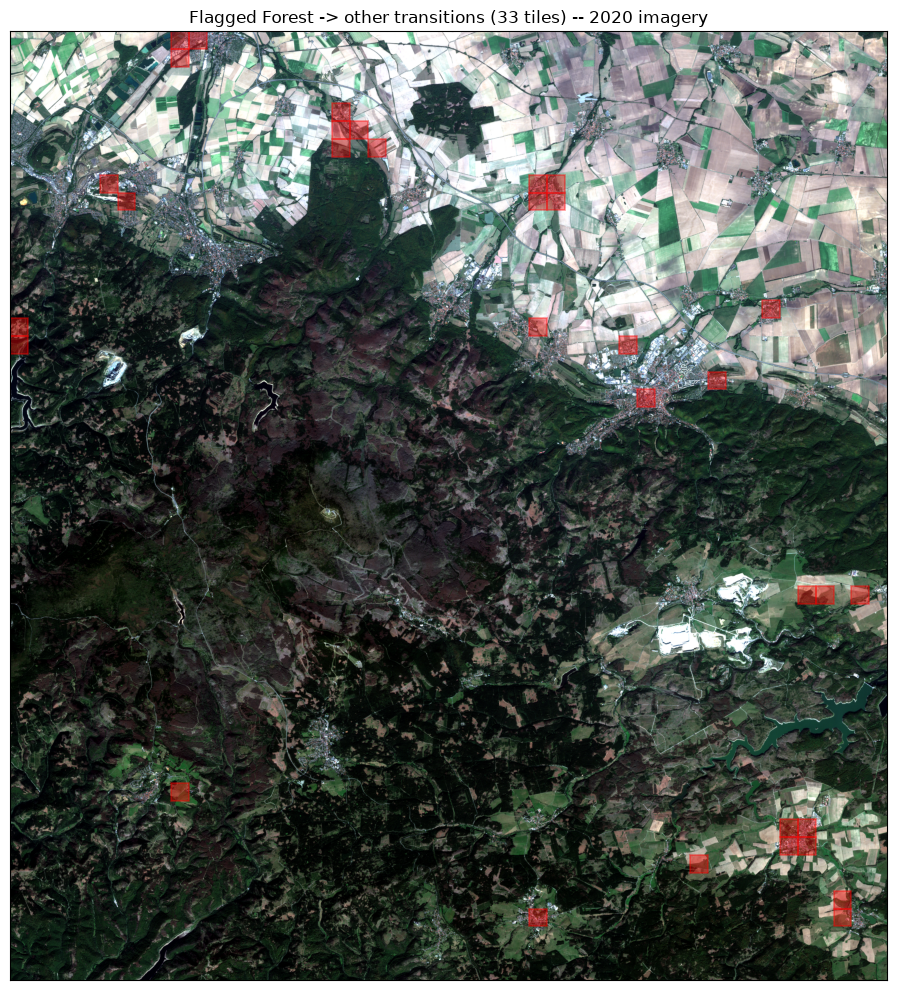

In [4]:
forest_loss = (before == "Forest") & (after != "Forest")
n_flagged = forest_loss.sum()
print(f"{n_flagged} / {before.size} tiles flagged as Forest -> other ({n_flagged / before.size:.1%})")

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(composite_after)

rows, cols = np.where(forest_loss)
for r, c in zip(rows, cols):
    rect = plt.Rectangle(
        (c * TILE_SIZE, r * TILE_SIZE), TILE_SIZE, TILE_SIZE,
        linewidth=1.2, edgecolor="red", facecolor="red", alpha=0.4,
    )
    ax.add_patch(rect)

ax.set_title(f"Flagged Forest -> other transitions ({n_flagged} tiles) -- 2020 imagery")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## Takeaway

The mechanism works end to end: two dated classifications, diffed, visualized on real imagery -- with the existing model and pipeline, no retraining, one new standalone script. What it does **not** yet give is a trustworthy result on this specific area: the raw class counts (`Forest` going *up*, `SeaLake` implausibly covering most of a mountain in 2017) point to a calibration mismatch, not real forest loss. Making this rigorous would mean re-running the label-free `REFLECTANCE_MAX` search (`calibrate_reflectance.py`'s method) on Harz tiles specifically, for each date, before trusting the diff.